# Risk-Based Credit Default Prediction Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_train = pd.read_csv("GiveMeSomeCredit-training.csv")
df_train.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [8]:
print("Shape:", df_train.shape)
df_train.info()
df_train.describe()

Shape: (150000, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.00,150000.00,150000.00,150000.00,150000.00,120269.00,150000.00,150000.00,150000.00,150000.00,146076.00
mean,0.07,6.05,52.30,0.42,353.01,6670.22,8.45,0.27,1.02,0.24,0.76
std,0.25,249.76,14.77,4.19,2037.82,14384.67,5.15,4.17,1.13,4.16,1.12
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.03,41.00,0.00,0.18,3400.00,5.00,0.00,0.00,0.00,0.00
50%,0.00,0.15,52.00,0.00,0.37,5400.00,8.00,0.00,1.00,0.00,0.00
75%,0.00,0.56,63.00,0.00,0.87,8249.00,11.00,0.00,2.00,0.00,1.00
max,1.00,50708.00,109.00,98.00,329664.00,3008750.00,58.00,98.00,54.00,98.00,20.00


In [4]:
pd.set_option('display.float_format', '{:.2f}'.format)  # Displays scientific numbers (Real numbers) as normal numbers

In [5]:
df_train.drop("Unnamed: 0", axis=1, inplace=True)

df_train.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [9]:
df_train['SeriousDlqin2yrs'].value_counts(normalize=True)

SeriousDlqin2yrs
0   0.93
1   0.07
Name: proportion, dtype: float64

(0.0, 153971.40000000002)

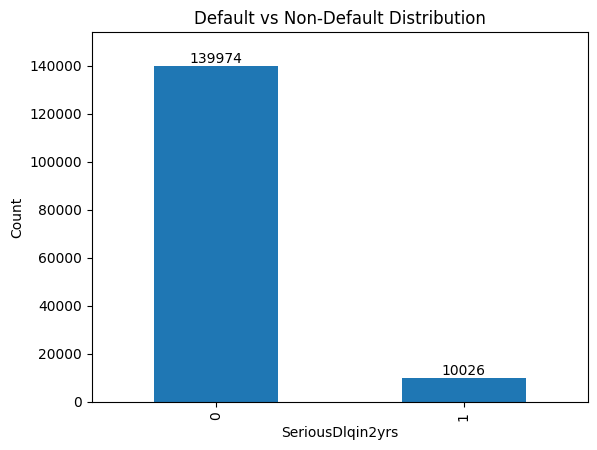

In [14]:
# Checking how balanced is the target data
target_Count = df_train["SeriousDlqin2yrs"].value_counts()
ax = target_Count.plot(kind='bar')

plt.ylabel("Count")
plt.title("Default vs Non-Default Distribution")

for container in ax.containers:
    ax.bar_label(container)

plt.ylim(0, max(target_Count) * 1.1)

In [15]:
missing = df_train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

MonthlyIncome         29731
NumberOfDependents     3924
dtype: int64


In [17]:
missing_percent = (df_train.isnull().sum()/len(df_train))*100
missing_percent.sort_values(ascending=False)

MonthlyIncome                          19.82
NumberOfDependents                      2.62
SeriousDlqin2yrs                        0.00
age                                     0.00
RevolvingUtilizationOfUnsecuredLines    0.00
DebtRatio                               0.00
NumberOfTime30-59DaysPastDueNotWorse    0.00
NumberOfOpenCreditLinesAndLoans         0.00
NumberOfTimes90DaysLate                 0.00
NumberRealEstateLoansOrLines            0.00
NumberOfTime60-89DaysPastDueNotWorse    0.00
dtype: float64

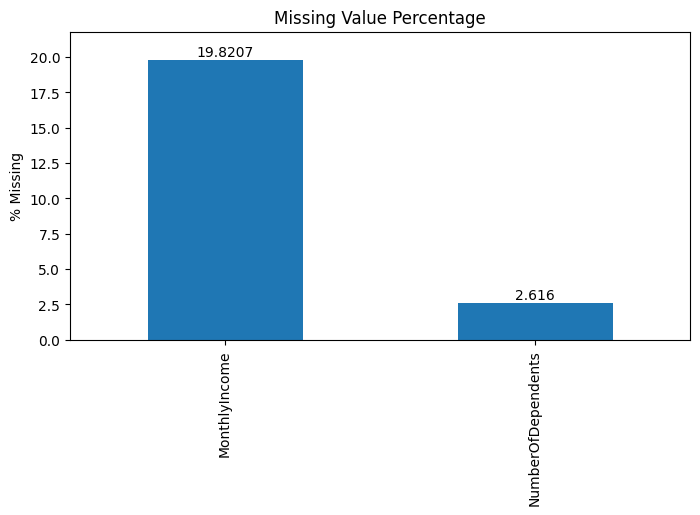

In [19]:
plt.figure(figsize=(8,4))
ax = missing_percent[missing_percent > 0].plot(kind='bar')
plt.title("Missing Value Percentage")
plt.ylabel("% Missing")

for container in ax.containers:
    ax.bar_label(container)

plt.ylim(0, max(missing_percent) * 1.1)

plt.show()

In [6]:
target_feature = "SeriousDlqin2yrs" # Target Feature

# Get all features except target
features_df = df_train.drop(columns=[target_feature])

num_feature = features_df.select_dtypes(include=['number']).columns.tolist()
cat_feature = features_df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"There are {len(num_feature)} Numerical features: {num_feature}")
print(f"There are {len(cat_feature)} Categorical features: {cat_feature}")

There are 10 Numerical features: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']
There are 0 Categorical features: []


In [ ]:
df_train.groupby(df_train["MonthlyIncome"].isnull())["SeriousDlqin2yrs"].mean()

MonthlyIncome
False    0.069486
True     0.056137
Name: SeriousDlqin2yrs, dtype: float64

In [ ]:
df_train.groupby(df_train["NumberOfDependents"].isnull())["SeriousDlqin2yrs"].count()

NumberOfDependents
False    146076
True       3924
Name: SeriousDlqin2yrs, dtype: int64

In [62]:
df_train.groupby(df_train["NumberOfDependents"])["SeriousDlqin2yrs"].count()

NumberOfDependents
0.00     86902
1.00     26316
2.00     19522
3.00      9483
4.00      2862
5.00       746
6.00       158
7.00        51
8.00        24
9.00         5
10.00        5
13.00        1
20.00        1
Name: SeriousDlqin2yrs, dtype: int64

In [64]:
def apply_IQR(dataframe, num_feature):
    for i in num_feature:
        IQR = dataframe[i].quantile(0.75) - dataframe[i].quantile(0.25)
        Lower_fence = dataframe[i].quantile(0.25) - (IQR * 3)
        Upper_fence = dataframe[i].quantile(0.75) + (IQR * 3)
        print('Factor {i} outliers are values < {lowerboundary} or > {upperboundary}'.format \
              (i=i,lowerboundary=Lower_fence, upperboundary=Upper_fence))
        
        dataframe[i] = np.where(dataframe[i]<Lower_fence, Lower_fence, dataframe[i])
        dataframe[i] = np.where(dataframe[i]>Upper_fence, Upper_fence, dataframe[i])

apply_IQR(df_train, df_train.columns)

Factor Unnamed: 0 outliers are values < -187497.75 or > 337498.75
Factor SeriousDlqin2yrs outliers are values < 0.0 or > 0.0
Factor RevolvingUtilizationOfUnsecuredLines outliers are values < -1.5576689744999999 or > 2.146582664
Factor age outliers are values < -25.0 or > 129.0
Factor NumberOfTime30-59DaysPastDueNotWorse outliers are values < 0.0 or > 0.0
Factor DebtRatio outliers are values < -1.9044659907499997 or > 2.9477935962499995
Factor MonthlyIncome outliers are values < -11147.0 or > 22796.0
Factor NumberOfOpenCreditLinesAndLoans outliers are values < -13.0 or > 29.0
Factor NumberOfTimes90DaysLate outliers are values < 0.0 or > 0.0
Factor NumberRealEstateLoansOrLines outliers are values < -6.0 or > 8.0
Factor NumberOfTime60-89DaysPastDueNotWorse outliers are values < 0.0 or > 0.0
Factor NumberOfDependents outliers are values < -3.0 or > 4.0
